# AGP Effect Size Comparison: Pre vs Post Case-Control Matching
## SAMPLE-SIZE CONTROLLED VERSION

This notebook provides a **fair comparison** of effect sizes before and after CCM by:

1. **Subsampling pre-CCM** to match post-CCM sample sizes (random subsampling)
2. **Bootstrap iterations** to get confidence intervals for pre-CCM effect sizes
3. **Proper statistical testing** comparing distributions of effect sizes

**Critical Issue Being Addressed:**
- Pre-CCM: 169 cases vs 4672 controls = 4841 total (27.6:1 imbalance!)
- Post-CCM: 169 cases vs 169 controls = 338 total (balanced)

Without controlling for this, pre-CCM effect sizes would be artificially inflated.

## 1. Setup and Imports

In [1]:
# Core imports
import pandas as pd
import numpy as np
import warnings
import os
warnings.filterwarnings('ignore')

# QIIME2 imports
from qiime2 import Artifact, Metadata
from qiime2.plugins.feature_table.methods import filter_samples
from qiime2.plugins.diversity.methods import filter_distance_matrix
from qiime2.plugins.diversity.actions import beta_phylogenetic, beta

# QUPID imports
import qupid
from qupid import match_by_multiple, match_by_single
from qupid.casematch import CaseMatchOneToMany, CaseMatchOneToOne, CaseMatchCollection

# Statistical imports
from scipy import stats
from skbio.stats.distance import DistanceMatrix, permanova
from skbio.stats.ordination import pcoa

# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
%matplotlib inline

# Set style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Configuration for AGP Dataset

In [ ]:
# ============================================================================
# CONFIGURATION FOR AGP DATASET
# ============================================================================
import os

DATASET_NAME = "AGP"

# File paths — override via env vars so the notebook runs on any host.
# Defaults are the barnacle2 cluster paths (behaviour unchanged on barnacle).
BASE_PATH = os.environ.get(
    "AGP_BASE_PATH",
    "/projects/tmi-public-results/22Oct2025/human-gut/WGS/10317",
)
FEATURE_TABLE_PATH = os.environ.get(
    "AGP_FEATURE_TABLE", f"{BASE_PATH}/raw.minfeat.mindepth.biom.qza"
)
METADATA_PATH = os.environ.get(
    "AGP_METADATA", f"{BASE_PATH}/metadata-by-status/All_good.tsv"
)
PCOA_PATH = os.environ.get(
    "AGP_PCOA", f"{BASE_PATH}/beta/pcoa/unweighted_unifrac.qza"
)
PHYLOGENY_PATH = os.environ.get(
    "GG2_PHYLOGENY", "/databases/gg/2024.09/2024.09.phylogeny.id.nwk.qza"
)

# Case-control column configuration
CASE_CONTROL_COLUMN = 'ibd'
CASE_VALUES = ['Diagnosed by a medical professional (doctor, physician assistant)']
CONTROL_VALUE = 'I do not have this condition'

# Matching criteria
MATCHING_CATEGORIES = [
    'sex',
    'age_cat',
    'bmi_cat',
]
NUMERIC_CATEGORIES = []
TOLERANCE_MAP = {}

# Effect size categories to evaluate
EFFECT_SIZE_CATEGORIES = [
    # Demographics
    'age_cat', 'sex', 'race', 'bmi_cat',
    # Geography
    'country', 'country_residence',
    # Diet
    'diet_type', 'types_of_plants', 'alcohol_frequency', 'alcohol_consumption',
    'vegetable_frequency', 'fruit_frequency', 'meat_eggs_frequency',
    'milk_cheese_frequency', 'whole_grain_frequency', 'salted_snacks_frequency',
    'sugary_sweets_frequency', 'prepared_meals_frequency', 'high_fat_red_meat_frequency',
    # Lifestyle
    'exercise_frequency', 'sleep_duration', 'smoking_frequency',
    'probiotic_frequency', 'antibiotic_history',
    # Health
    'bowel_movement_frequency', 'bowel_movement_quality',
    'ibd', 'diabetes', 'cardiovascular_disease', 'mental_illness',
    'skin_condition', 'thyroid', 'autoimmune',
    # Oral health
    'flossing_frequency', 'teethbrushing_frequency',
    # Other
    'chickenpox', 'cosmetics_frequency',
]

# Analysis parameters
N_ITERATIONS = 100      # Number of CCM iterations
N_BOOTSTRAP = 100       # Number of bootstrap iterations for pre-CCM
N_PERMUTATIONS = 999    # Permutations for PERMANOVA
RANDOM_SEED = 42

# Output directory
OUTPUT_DIR = 'agp_ccm_analysis_controlled'
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.random.seed(RANDOM_SEED)

## 3. Load Data

In [3]:
# Load metadata
print("Loading metadata...")
metadata_df = pd.read_csv(METADATA_PATH, sep='\t', index_col=0)

if metadata_df.index[0].startswith('#'):
    metadata_df = pd.read_csv(METADATA_PATH, sep='\t', index_col=0, skiprows=1)

print(f"Metadata shape: {metadata_df.shape}")

# Check case-control distribution
print(f"\nDistribution in '{CASE_CONTROL_COLUMN}' column:")
print(metadata_df[CASE_CONTROL_COLUMN].value_counts())

Loading metadata...
Metadata shape: (5236, 86)

Distribution in 'ibd' column:
I do not have this condition                                         4672
not provided                                                          335
Diagnosed by a medical professional (doctor, physician assistant)     169
Self-diagnosed                                                         45
Diagnosed by an alternative medicine practitioner                      13
not collected                                                           2
Name: ibd, dtype: int64


In [4]:
# Load feature table
print("\nLoading feature table...")
table_artifact = Artifact.load(FEATURE_TABLE_PATH)
table_df = table_artifact.view(pd.DataFrame)
print(f"Feature table shape: {table_df.shape}")

# Check overlap
common_samples = list(set(metadata_df.index) & set(table_df.index))
print(f"Samples in both metadata and feature table: {len(common_samples)}")

# Filter metadata
metadata_df = metadata_df.loc[metadata_df.index.isin(common_samples)]


Loading feature table...
Feature table shape: (5236, 2019)
Samples in both metadata and feature table: 5236


## 4. Prepare Case-Control Groups

In [5]:
def prepare_case_control_groups(metadata_df, case_control_col, case_values, control_value):
    """Separate metadata into focus (cases) and background (controls)."""
    if isinstance(case_values, str):
        case_values = [case_values]
    
    all_values = case_values + [control_value]
    relevant_samples = metadata_df[metadata_df[case_control_col].isin(all_values)].copy()
    relevant_samples['is_case'] = relevant_samples[case_control_col].isin(case_values).astype(int)
    
    focus = relevant_samples[relevant_samples['is_case'] == 1]
    background = relevant_samples[relevant_samples['is_case'] == 0]
    
    print(f"Cases (focus): {len(focus)} samples")
    print(f"Controls (background): {len(background)} samples")
    print(f"Imbalance ratio: 1:{len(background)/len(focus):.1f}")
    
    return focus, background, relevant_samples

focus, background, all_relevant = prepare_case_control_groups(
    metadata_df, CASE_CONTROL_COLUMN, CASE_VALUES, CONTROL_VALUE
)

Cases (focus): 169 samples
Controls (background): 4672 samples
Imbalance ratio: 1:27.6


In [6]:
# Check matching category distributions
print("\n=== Matching Category Distributions ===")
for cat in MATCHING_CATEGORIES:
    if cat in focus.columns:
        print(f"\n{cat}:")
        print(f"Cases: {focus[cat].value_counts().head(5).to_dict()}")
        print(f"Controls: {background[cat].value_counts().head(5).to_dict()}")


=== Matching Category Distributions ===

sex:
Cases: {'female': 121, 'male': 45, 'not provided': 3}
Controls: {'female': 3166, 'male': 1447, 'not provided': 49, 'other': 10}

age_cat:
Cases: {'30s': 38, '40s': 36, '20s': 29, '50s': 27, '60s': 27}
Controls: {'40s': 1046, '50s': 925, '30s': 912, '60s': 658, '20s': 613}

bmi_cat:
Cases: {'Normal': 82, 'Overweight': 47, 'Obese': 21, 'Underweight': 12, 'not provided': 7}
Controls: {'Normal': 2415, 'Overweight': 1111, 'Obese': 722, 'Underweight': 213, 'not provided': 211}


## 5. Compute Distance Matrix

In [7]:
def compute_distance_matrix(table_artifact, metric='braycurtis', phylogeny_path=None, sample_ids=None):
    """Compute beta diversity distance matrix."""
    if sample_ids is not None:
        filter_md = pd.DataFrame(index=sample_ids)
        filter_md['keep'] = 'yes'
        filter_md.index.name = 'sample-id'
        filter_metadata = Metadata(filter_md)
        table_artifact = filter_samples(table=table_artifact, metadata=filter_metadata).filtered_table
    
    if metric in ['unweighted_unifrac', 'weighted_unifrac']:
        if phylogeny_path is None:
            raise ValueError("Phylogeny required for UniFrac")
        phylogeny = Artifact.load(phylogeny_path)
        dm_artifact = beta_phylogenetic(table=table_artifact, phylogeny=phylogeny, metric=metric).distance_matrix
    else:
        dm_artifact = beta(table=table_artifact, metric=metric).distance_matrix
    
    dm = dm_artifact.view(DistanceMatrix)
    return dm_artifact, dm

In [8]:
# Filter to relevant samples
relevant_sample_ids = all_relevant.index.tolist()
common_samples = list(set(relevant_sample_ids) & set(table_df.index))

all_relevant = all_relevant.loc[all_relevant.index.isin(common_samples)]
focus = focus.loc[focus.index.isin(common_samples)]
background = background.loc[background.index.isin(common_samples)]

print(f"After filtering to feature table:")
print(f"  Cases: {len(focus)}")
print(f"  Controls: {len(background)}")

After filtering to feature table:
  Cases: 169
  Controls: 4672


In [9]:
# Compute distance matrix
# Using Bray-Curtis for speed; change to 'unweighted_unifrac' if phylogeny available
print("Computing distance matrix...")

try:
    dm_artifact, dm_full = compute_distance_matrix(
        table_artifact, 
        metric='unweighted_unifrac',
        phylogeny_path=PHYLOGENY_PATH,
        sample_ids=common_samples
    )
    DISTANCE_METRIC = 'Unweighted UniFrac'
except Exception as e:
    print(f"UniFrac failed ({e}), using Bray-Curtis")
    dm_artifact, dm_full = compute_distance_matrix(
        table_artifact, 
        metric='braycurtis',
        sample_ids=common_samples
    )
    DISTANCE_METRIC = 'Bray-Curtis'

print(f"Distance matrix computed: {dm_full.shape[0]} samples")
print(f"Metric: {DISTANCE_METRIC}")

Computing distance matrix...
Running external command line application. This may print messages to stdout and/or stderr.
The command being run is below. This command cannot be manually re-run as it will depend on temporary files that no longer exist.

Command:

ssu -i /tmp/qiime2/l1joseph/data/eb564d20-deb9-472a-b8c0-9bac60719163/data/feature-table.biom -t /tmp/qiime2/l1joseph/data/52e0fb90-d576-4f77-a07e-8f0b9dd78dda/data/tree.nwk -m unweighted -o /tmp/q2-LSMatFormat-9ymhwrnl



Compute failed in one_off: Table observation IDs are not a subset of the tree tips. This error can also be triggered if a node name contains a single quote (this is unlikely).


UniFrac failed (Command '['ssu', '-i', '/tmp/qiime2/l1joseph/data/eb564d20-deb9-472a-b8c0-9bac60719163/data/feature-table.biom', '-t', '/tmp/qiime2/l1joseph/data/52e0fb90-d576-4f77-a07e-8f0b9dd78dda/data/tree.nwk', '-m', 'unweighted', '-o', '/tmp/q2-LSMatFormat-9ymhwrnl']' returned non-zero exit status 1.), using Bray-Curtis
Distance matrix computed: 4841 samples
Metric: Bray-Curtis


## 6. Effect Size Calculation Functions

In [10]:
def calculate_effect_size_permanova(dm, metadata_df, category, permutations=999):
    """
    Calculate effect size (R²) using PERMANOVA.
    
    Returns the true R² (proportion of variance explained), not the pseudo-F statistic.
    
    R² = (F × df_between) / (F × df_between + df_within)
    
    where:
        df_between = n_groups - 1
        df_within = n_samples - n_groups
    """
    common_ids = list(set(dm.ids) & set(metadata_df.index))
    
    if len(common_ids) < 10:
        return None
    
    dm_filtered = dm.filter(common_ids)
    md_filtered = metadata_df.loc[common_ids, [category]].dropna()
    
    common_ids = list(set(dm_filtered.ids) & set(md_filtered.index))
    if len(common_ids) < 10:
        return None
    
    dm_filtered = dm_filtered.filter(common_ids)
    md_filtered = md_filtered.loc[common_ids]
    
    grouping = md_filtered[category]
    n_groups = grouping.nunique()
    n_samples = len(common_ids)
    
    if n_groups < 2:
        return None
    
    try:
        results = permanova(dm_filtered, grouping, permutations=permutations)
        
        # Extract pseudo-F statistic
        pseudo_f = results['test statistic']
        
        # Convert pseudo-F to R² (proportion of variance explained)
        df_between = n_groups - 1
        df_within = n_samples - n_groups
        r_squared = (pseudo_f * df_between) / (pseudo_f * df_between + df_within)
        
        # Return as percentage for easier interpretation
        r_squared_pct = r_squared * 100
        
        return {
            'r_squared': r_squared_pct,      # Now correctly R² as percentage
            'pseudo_f': pseudo_f,             # Also return F for reference
            'p_value': results['p-value'],
            'n_samples': n_samples,
            'n_groups': n_groups
        }
    except Exception as e:
        return None

## 7. Case-Control Matching

In [11]:
def perform_case_control_matching(focus, background, categories, tolerance_map=None, 
                                   n_iterations=100, numeric_categories=None):
    """Perform case-control matching using QUPID."""
    if numeric_categories is None:
        numeric_categories = []
    
    all_cats = categories + [c for c in numeric_categories if c not in categories]
    
    focus_clean = focus.dropna(subset=all_cats)
    background_clean = background.dropna(subset=all_cats)
    
    print(f"After cleaning:")
    print(f"  Cases: {len(focus_clean)} (dropped {len(focus) - len(focus_clean)})")
    print(f"  Controls: {len(background_clean)} (dropped {len(background) - len(background_clean)})")
    
    if tolerance_map is None:
        tolerance_map = {}
    
    cm = match_by_multiple(
        focus=focus_clean,
        background=background_clean,
        categories=all_cats,
        tolerance_map=tolerance_map,
        on_failure='ignore'
    )
    
    print(f"\nMatching results:")
    print(f"  Matched cases: {len(cm.cases)}")
    print(f"  Available controls: {len(cm.controls)}")
    
    matched_pairs = cm.create_matched_pairs(iterations=n_iterations, strict=False)
    
    return cm, matched_pairs, focus_clean, background_clean

# Perform matching
print("Performing case-control matching...")
cm, matched_pairs, focus_clean, background_clean = perform_case_control_matching(
    focus, background,
    categories=MATCHING_CATEGORIES,
    tolerance_map=TOLERANCE_MAP,
    n_iterations=N_ITERATIONS,
    numeric_categories=NUMERIC_CATEGORIES
)

Performing case-control matching...
After cleaning:
  Cases: 169 (dropped 0)
  Controls: 4672 (dropped 0)

Matching results:
  Matched cases: 169
  Available controls: 4148


## 8. Determine Target Sample Size

In [12]:
# Get sample sizes from CCM
cm_single = matched_pairs[0]
n_cases_matched = len(list(cm_single.cases))
n_controls_matched = len(list(cm_single.controls))

print("=" * 60)
print("SAMPLE SIZE ANALYSIS")
print("=" * 60)

print(f"\nPre-CCM (Full dataset):")
print(f"  Cases: {len(focus)}")
print(f"  Controls: {len(background)}")
print(f"  Total: {len(all_relevant)}")
print(f"  Imbalance: 1:{len(background)/len(focus):.1f}")

print(f"\nPost-CCM (Matched):")
print(f"  Cases: {n_cases_matched}")
print(f"  Controls: {n_controls_matched}")
print(f"  Total: {n_cases_matched + n_controls_matched}")
print(f"  Ratio: {n_cases_matched/n_controls_matched:.2f}")

# Target for fair comparison
TARGET_N_CASES = n_cases_matched
TARGET_N_CONTROLS = n_controls_matched
TARGET_TOTAL = TARGET_N_CASES + TARGET_N_CONTROLS

print(f"\n" + "=" * 60)
print(f"TARGET FOR PRE-CCM BOOTSTRAP:")
print(f"  {TARGET_N_CASES} cases + {TARGET_N_CONTROLS} controls = {TARGET_TOTAL} total")
print("=" * 60)

SAMPLE SIZE ANALYSIS

Pre-CCM (Full dataset):
  Cases: 169
  Controls: 4672
  Total: 4841
  Imbalance: 1:27.6

Post-CCM (Matched):
  Cases: 169
  Controls: 169
  Total: 338
  Ratio: 1.00

TARGET FOR PRE-CCM BOOTSTRAP:
  169 cases + 169 controls = 338 total


## 9. Sample-Size Controlled Pre-CCM Effect Sizes (Bootstrap)

**Key Innovation**: Randomly subsample to match CCM sample size, repeat N times

In [13]:
def calculate_bootstrap_effect_sizes(dm, metadata_df, categories, 
                                      n_cases, n_controls, 
                                      n_bootstrap=100, permutations=999,
                                      random_seed=42):
    """
    Calculate effect sizes using bootstrap subsampling to control for sample size.
    """
    np.random.seed(random_seed)
    
    case_ids = metadata_df[metadata_df['is_case'] == 1].index.tolist()
    control_ids = metadata_df[metadata_df['is_case'] == 0].index.tolist()
    
    case_ids = [s for s in case_ids if s in dm.ids]
    control_ids = [s for s in control_ids if s in dm.ids]
    
    print(f"Available: {len(case_ids)} cases, {len(control_ids)} controls")
    print(f"Target: {n_cases} cases, {n_controls} controls")
    
    n_cases = min(n_cases, len(case_ids))
    n_controls = min(n_controls, len(control_ids))
    
    all_results = []
    
    print(f"\nRunning {n_bootstrap} bootstrap iterations...")
    
    for i in range(n_bootstrap):
        if (i + 1) % 20 == 0:
            print(f"  Iteration {i + 1}/{n_bootstrap}")
        
        sampled_cases = np.random.choice(case_ids, size=n_cases, replace=False)
        sampled_controls = np.random.choice(control_ids, size=n_controls, replace=False)
        sampled_ids = list(sampled_cases) + list(sampled_controls)
        
        dm_sub = dm.filter(sampled_ids)
        md_sub = metadata_df.loc[sampled_ids]
        
        for cat in categories:
            if cat not in md_sub.columns:
                continue
            
            effect = calculate_effect_size_permanova(dm_sub, md_sub, cat, permutations=permutations)
            
            if effect is not None:
                all_results.append({
                    'iteration': i,
                    'category': cat,
                    'r_squared': effect['r_squared'],
                    'p_value': effect['p_value'],
                    'n_samples': effect['n_samples'],
                    'n_groups': effect['n_groups']
                })
    
    results_df = pd.DataFrame(all_results)
    
    if len(results_df) > 0:
        summary = results_df.groupby('category').agg({
            'r_squared': ['mean', 'std', 'min', 'max'],
            'p_value': 'mean',
            'n_samples': 'mean'
        }).reset_index()
        summary.columns = ['category', 'r_squared_mean', 'r_squared_std', 
                          'r_squared_min', 'r_squared_max', 'p_value', 'n_samples']
        summary['condition'] = 'Pre-CCM (bootstrap)'
    else:
        summary = pd.DataFrame()
    
    return results_df, summary

In [14]:
# Calculate sample-size controlled Pre-CCM effect sizes
print("="*60)
print("CALCULATING SAMPLE-SIZE CONTROLLED PRE-CCM EFFECT SIZES")
print("(Bootstrap subsampling to match CCM sample size)")
print("="*60 + "\n")

effect_sizes_pre_all, effect_sizes_pre = calculate_bootstrap_effect_sizes(
    dm_full,
    all_relevant,
    EFFECT_SIZE_CATEGORIES,
    n_cases=TARGET_N_CASES,
    n_controls=TARGET_N_CONTROLS,
    n_bootstrap=N_BOOTSTRAP,
    permutations=N_PERMUTATIONS,
    random_seed=RANDOM_SEED
)

print(f"\nPre-CCM effect sizes calculated for {len(effect_sizes_pre)} categories")
effect_sizes_pre.sort_values('r_squared_mean', ascending=False).head(15)

CALCULATING SAMPLE-SIZE CONTROLLED PRE-CCM EFFECT SIZES
(Bootstrap subsampling to match CCM sample size)

Available: 169 cases, 4672 controls
Target: 169 cases, 169 controls

Running 100 bootstrap iterations...
  Iteration 20/100
  Iteration 40/100
  Iteration 60/100
  Iteration 80/100
  Iteration 100/100

Pre-CCM effect sizes calculated for 37 categories


,category,r_squared_mean,r_squared_std,r_squared_min,r_squared_max,p_value,n_samples,condition
12,country_residence,3.317411,0.378628,2.525301,4.364371,0.00100,338.0,Pre-CCM (bootstrap)
21,mental_illness,2.563315,0.468472,1.501493,3.953481,0.00117,338.0,Pre-CCM (bootstrap)
8,cardiovascular_disease,2.376492,0.610495,1.345522,4.203349,0.00279,338.0,Pre-CCM (bootstrap)
25,race,2.363837,0.188116,1.849210,2.868305,0.00100,338.0,Pre-CCM (bootstrap)
11,country,2.227311,0.546261,1.299373,4.077832,0.01126,96.5,Pre-CCM (bootstrap)
17,fruit_frequency,2.123215,0.346495,1.391814,3.067512,0.00115,338.0,Pre-CCM (bootstrap)
22,milk_cheese_frequency,1.947362,0.378850,1.241287,3.065132,0.00271,338.0,Pre-CCM (bootstrap)
36,whole_grain_frequency,1.902646,0.348658,1.144563,2.849622,0.00325,338.0,Pre-CCM (bootstrap)
34,types_of_plants,1.823832,0.288960,1.268622,2.833372,0.00240,338.0,Pre-CCM (bootstrap)
31,sugary_sweets_frequency,1.776634,0.319199,1.195360,2.684516,0.00455,338.0,Pre-CCM (bootstrap)


## 10. Post-CCM Effect Sizes

In [15]:
def calculate_matched_effect_sizes(matched_pairs, dm, metadata_df, categories, 
                                    permutations=999, n_iterations_to_use=None):
    """Calculate effect sizes for matched pair iterations."""
    all_results = []
    
    if n_iterations_to_use is None:
        n_iterations_to_use = len(matched_pairs.case_matches)
    n_use = min(n_iterations_to_use, len(matched_pairs.case_matches))
    
    print(f"Calculating effect sizes for {n_use} CCM iterations...")
    
    for i in range(n_use):
        if (i + 1) % 20 == 0:
            print(f"  Iteration {i + 1}/{n_use}")
        
        cm_single = matched_pairs[i]
        
        cases = list(cm_single.cases)
        controls = list(cm_single.controls)
        matched_samples = [s for s in cases + controls if s in dm.ids]
        
        if len(matched_samples) < 20:
            continue
        
        dm_matched = dm.filter(matched_samples)
        md_matched = metadata_df.loc[metadata_df.index.isin(matched_samples)]
        
        for cat in categories:
            if cat not in md_matched.columns:
                continue
            
            effect = calculate_effect_size_permanova(dm_matched, md_matched, cat, permutations=permutations)
            
            if effect is not None:
                all_results.append({
                    'iteration': i,
                    'category': cat,
                    'r_squared': effect['r_squared'],
                    'p_value': effect['p_value'],
                    'n_samples': effect['n_samples']
                })
    
    results_df = pd.DataFrame(all_results)
    
    if len(results_df) > 0:
        summary = results_df.groupby('category').agg({
            'r_squared': ['mean', 'std', 'min', 'max'],
            'p_value': 'mean',
            'n_samples': 'mean'
        }).reset_index()
        summary.columns = ['category', 'r_squared_mean', 'r_squared_std',
                          'r_squared_min', 'r_squared_max', 'p_value', 'n_samples']
        summary['condition'] = 'Post-CCM'
    else:
        summary = pd.DataFrame()
    
    return results_df, summary

In [16]:
print("="*60)
print("CALCULATING POST-CCM EFFECT SIZES")
print("="*60 + "\n")

effect_sizes_post_all, effect_sizes_post = calculate_matched_effect_sizes(
    matched_pairs,
    dm_full,
    all_relevant,
    EFFECT_SIZE_CATEGORIES,
    permutations=N_PERMUTATIONS,
    n_iterations_to_use=N_ITERATIONS
)

print(f"\nPost-CCM effect sizes calculated")
effect_sizes_post.sort_values('r_squared_mean', ascending=False).head(15)

CALCULATING POST-CCM EFFECT SIZES

Calculating effect sizes for 100 CCM iterations...
  Iteration 20/100
  Iteration 40/100
  Iteration 60/100
  Iteration 80/100
  Iteration 100/100

Post-CCM effect sizes calculated


,category,r_squared_mean,r_squared_std,r_squared_min,r_squared_max,p_value,n_samples,condition
12,country_residence,3.500595,0.361836,2.820989,4.503143,0.00100,338.00,Post-CCM
21,mental_illness,2.896240,0.550753,1.813321,4.727832,0.00100,338.00,Post-CCM
8,cardiovascular_disease,2.712043,0.716607,1.669783,5.123667,0.00120,338.00,Post-CCM
17,fruit_frequency,2.375272,0.342837,1.676625,3.436583,0.00100,338.00,Post-CCM
25,race,2.363079,0.203927,1.947842,3.122662,0.00100,338.00,Post-CCM
11,country,2.255895,0.457820,1.137852,3.485298,0.01175,95.45,Post-CCM
22,milk_cheese_frequency,2.138017,0.353784,1.361039,3.119130,0.00113,338.00,Post-CCM
36,whole_grain_frequency,2.054114,0.344501,1.323120,2.961161,0.00122,338.00,Post-CCM
35,vegetable_frequency,2.020677,0.344937,1.307719,3.278543,0.00139,338.00,Post-CCM
31,sugary_sweets_frequency,1.991506,0.336546,1.196347,2.807772,0.00222,338.00,Post-CCM


## 11. Case-Control Effect Sizes

In [17]:
print("="*60)
print("CALCULATING CASE-CONTROL (is_case) EFFECT SIZES")
print("="*60 + "\n")

# Pre-CCM (bootstrap)
cc_pre_all, cc_pre_summary = calculate_bootstrap_effect_sizes(
    dm_full,
    all_relevant,
    ['is_case'],
    n_cases=TARGET_N_CASES,
    n_controls=TARGET_N_CONTROLS,
    n_bootstrap=N_BOOTSTRAP,
    permutations=N_PERMUTATIONS,
    random_seed=RANDOM_SEED + 1
)

# Post-CCM
cc_post_all, cc_post_summary = calculate_matched_effect_sizes(
    matched_pairs,
    dm_full,
    all_relevant,
    ['is_case'],
    permutations=N_PERMUTATIONS,
    n_iterations_to_use=N_ITERATIONS
)

print(f"\n" + "="*60)
print("CASE-CONTROL EFFECT SIZE COMPARISON")
print("="*60)
print(f"Pre-CCM (bootstrap): R² = {cc_pre_all['r_squared'].mean():.4f} ± {cc_pre_all['r_squared'].std():.4f}")
print(f"Post-CCM:            R² = {cc_post_all['r_squared'].mean():.4f} ± {cc_post_all['r_squared'].std():.4f}")

delta = cc_post_all['r_squared'].mean() - cc_pre_all['r_squared'].mean()
pct = delta / cc_pre_all['r_squared'].mean() * 100 if cc_pre_all['r_squared'].mean() > 0 else 0
print(f"\nChange: {delta:+.4f} ({pct:+.1f}%)")

CALCULATING CASE-CONTROL (is_case) EFFECT SIZES

Available: 169 cases, 4672 controls
Target: 169 cases, 169 controls

Running 100 bootstrap iterations...
  Iteration 20/100
  Iteration 40/100
  Iteration 60/100
  Iteration 80/100
  Iteration 100/100
Calculating effect sizes for 100 CCM iterations...
  Iteration 20/100
  Iteration 40/100
  Iteration 60/100
  Iteration 80/100
  Iteration 100/100

CASE-CONTROL EFFECT SIZE COMPARISON
Pre-CCM (bootstrap): R² = 1.3514 ± 0.2502
Post-CCM:            R² = 1.5381 ± 0.2989

Change: +0.1867 (+13.8%)


## 12. Statistical Comparison

In [18]:
def compare_effect_sizes_fair(pre_all_df, post_all_df):
    """Compare pre and post CCM effect sizes with proper statistics."""
    results = []
    
    categories = set(pre_all_df['category'].unique()) & set(post_all_df['category'].unique())
    
    for cat in categories:
        pre_vals = pre_all_df[pre_all_df['category'] == cat]['r_squared'].values
        post_vals = post_all_df[post_all_df['category'] == cat]['r_squared'].values
        
        if len(pre_vals) < 2 or len(post_vals) < 2:
            continue
        
        t_stat, p_val_two = stats.ttest_ind(pre_vals, post_vals)
        u_stat, p_val_mw = stats.mannwhitneyu(pre_vals, post_vals, alternative='two-sided')
        
        pooled_std = np.sqrt((pre_vals.std()**2 + post_vals.std()**2) / 2)
        cohens_d = (post_vals.mean() - pre_vals.mean()) / pooled_std if pooled_std > 0 else 0
        
        results.append({
            'category': cat,
            'pre_mean': pre_vals.mean(),
            'pre_std': pre_vals.std(),
            'post_mean': post_vals.mean(),
            'post_std': post_vals.std(),
            'delta': post_vals.mean() - pre_vals.mean(),
            'pct_change': ((post_vals.mean() - pre_vals.mean()) / pre_vals.mean() * 100) if pre_vals.mean() > 0 else 0,
            't_statistic': t_stat,
            'p_value_ttest': p_val_two,
            'p_value_mannwhitney': p_val_mw,
            'cohens_d': cohens_d,
            'significant': p_val_two < 0.05
        })
    
    return pd.DataFrame(results)

comparison_df = compare_effect_sizes_fair(effect_sizes_pre_all, effect_sizes_post_all)

print("=== Effect Size Comparison (Sample-Size Controlled) ===")
print(comparison_df.sort_values('pre_mean', ascending=False).to_string())

=== Effect Size Comparison (Sample-Size Controlled) ===
                       category  pre_mean   pre_std  post_mean  post_std     delta  pct_change  t_statistic  p_value_ttest  p_value_mannwhitney  cohens_d  significant
34            country_residence  3.317411  0.376730   3.500595  0.360022  0.183184    5.521882    -3.497726   5.793389e-04         7.432740e-04  0.497145         True
32               mental_illness  2.563315  0.466124   2.896240  0.547992  0.332925   12.988066    -4.604480   7.385040e-06         9.590807e-06  0.654452         True
30       cardiovascular_disease  2.376492  0.607435   2.712043  0.713015  0.335551   14.119585    -3.564389   4.571031e-04         8.264594e-04  0.506620         True
22                         race  2.363837  0.187173   2.363079  0.202905 -0.000758   -0.032069     0.027323   9.782297e-01         7.203759e-01 -0.003884        False
2                       country  2.227311  0.543523   2.255895  0.455525  0.028585    1.283366    -0.401051  

In [19]:
# Case-control statistical test
print("\n=== Case-Control Statistical Test ===")

pre_cc = cc_pre_all['r_squared'].values
post_cc = cc_post_all['r_squared'].values

t_stat, p_val = stats.ttest_ind(pre_cc, post_cc)
u_stat, p_val_mw = stats.mannwhitneyu(pre_cc, post_cc, alternative='two-sided')

print(f"\nPre-CCM (n={len(pre_cc)}):  R² = {pre_cc.mean():.4f} ± {pre_cc.std():.4f}")
print(f"Post-CCM (n={len(post_cc)}): R² = {post_cc.mean():.4f} ± {post_cc.std():.4f}")
print(f"\nt-test: t={t_stat:.3f}, p={p_val:.4e}")
print(f"Mann-Whitney U: p={p_val_mw:.4e}")
print(f"\nSignificant difference: {'Yes' if p_val < 0.05 else 'No'}")


=== Case-Control Statistical Test ===

Pre-CCM (n=100):  R² = 1.3514 ± 0.2489
Post-CCM (n=100): R² = 1.5381 ± 0.2974

t-test: t=-4.789, p=3.2743e-06
Mann-Whitney U: p=2.2007e-06

Significant difference: Yes


## 13. Visualization

Saved: agp_ccm_analysis_controlled/AGP_effect_size_controlled.png


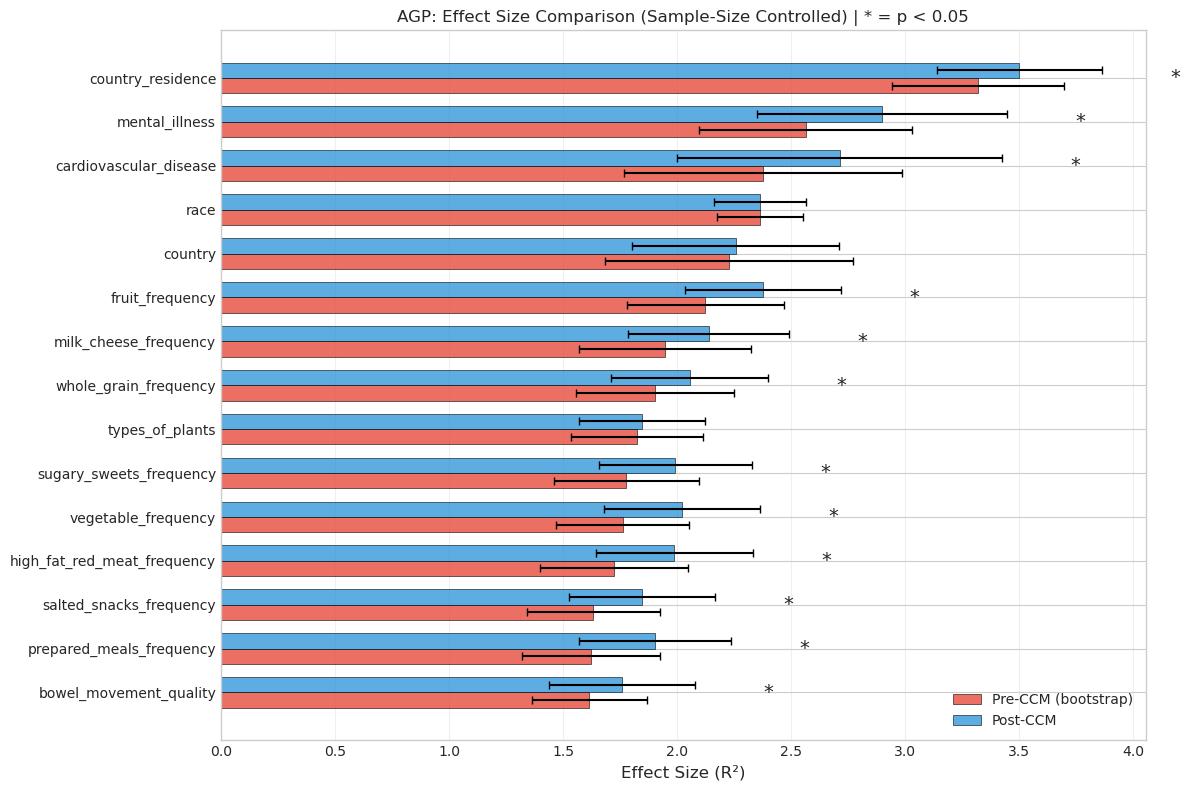

In [25]:
def plot_effect_size_comparison_controlled(comparison_df, dataset_name, n_top=15, output_path=None):
    """Bar chart with error bars for fair comparison."""
    plot_data = comparison_df.sort_values('pre_mean', ascending=True).tail(n_top)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    y_pos = np.arange(len(plot_data))
    height = 0.35
    
    bars1 = ax.barh(y_pos - height/2, plot_data['pre_mean'], height, 
                    xerr=plot_data['pre_std'], capsize=3,
                    label='Pre-CCM (bootstrap)', color='#e74c3c', alpha=0.8,
                    edgecolor='black', linewidth=0.5)
    
    bars2 = ax.barh(y_pos + height/2, plot_data['post_mean'], height,
                    xerr=plot_data['post_std'], capsize=3,
                    label='Post-CCM', color='#3498db', alpha=0.8,
                    edgecolor='black', linewidth=0.5)
    
    for i, (_, row) in enumerate(plot_data.iterrows()):
        if row['significant']:
            max_val = max(row['pre_mean'] + row['pre_std'], row['post_mean'] + row['post_std'])
            ax.text(max_val + 0.3, y_pos[i], '*', fontsize=14, ha='left', va='center')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_data['category'], fontsize=10)
    ax.set_xlabel('Effect Size (R²)', fontsize=12)
    ax.set_title(f'{dataset_name}: Effect Size Comparison (Sample-Size Controlled) | * = p < 0.05',
                 fontsize=12)
    ax.legend(loc='lower right', fontsize=10)
    
    ax.set_axisbelow(True)
    ax.xaxis.grid(True, linestyle='-', alpha=0.3)
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved: {output_path}")
    
    plt.show()
    return fig

fig1 = plot_effect_size_comparison_controlled(
    comparison_df,
    DATASET_NAME,
    n_top=15,
    output_path=os.path.join(OUTPUT_DIR, f'{DATASET_NAME}_effect_size_controlled.png')
)

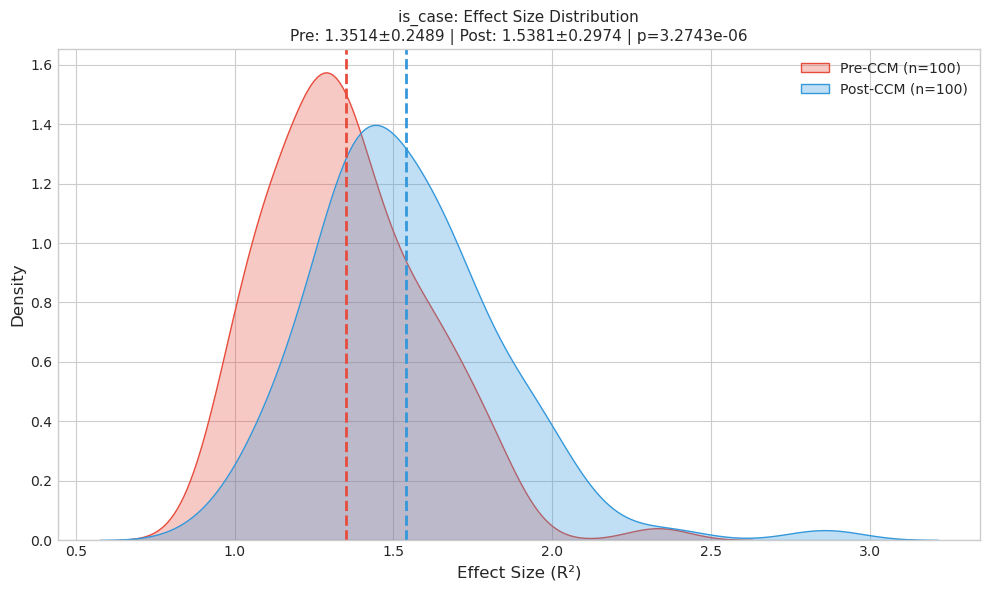

In [21]:
def plot_distribution_comparison(pre_all_df, post_all_df, category, output_path=None):
    """Overlapping distributions for a category."""
    pre_vals = pre_all_df[pre_all_df['category'] == category]['r_squared'].values
    post_vals = post_all_df[post_all_df['category'] == category]['r_squared'].values
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    sns.kdeplot(pre_vals, ax=ax, color='#e74c3c', fill=True, alpha=0.3, 
                label=f'Pre-CCM (n={len(pre_vals)})')
    sns.kdeplot(post_vals, ax=ax, color='#3498db', fill=True, alpha=0.3,
                label=f'Post-CCM (n={len(post_vals)})')
    
    ax.axvline(pre_vals.mean(), color='#e74c3c', linestyle='--', linewidth=2)
    ax.axvline(post_vals.mean(), color='#3498db', linestyle='--', linewidth=2)
    
    t_stat, p_val = stats.ttest_ind(pre_vals, post_vals)
    
    ax.set_xlabel('Effect Size (R²)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'{category}: Effect Size Distribution\n'
                 f'Pre: {pre_vals.mean():.4f}±{pre_vals.std():.4f} | '
                 f'Post: {post_vals.mean():.4f}±{post_vals.std():.4f} | '
                 f'p={p_val:.4e}', fontsize=11)
    ax.legend()
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    
    plt.show()
    return fig

# Case-control distribution
fig2 = plot_distribution_comparison(
    cc_pre_all, cc_post_all, 'is_case',
    output_path=os.path.join(OUTPUT_DIR, f'{DATASET_NAME}_case_control_dist.png')
)

Saved: agp_ccm_analysis_controlled/AGP_scatter_controlled.png


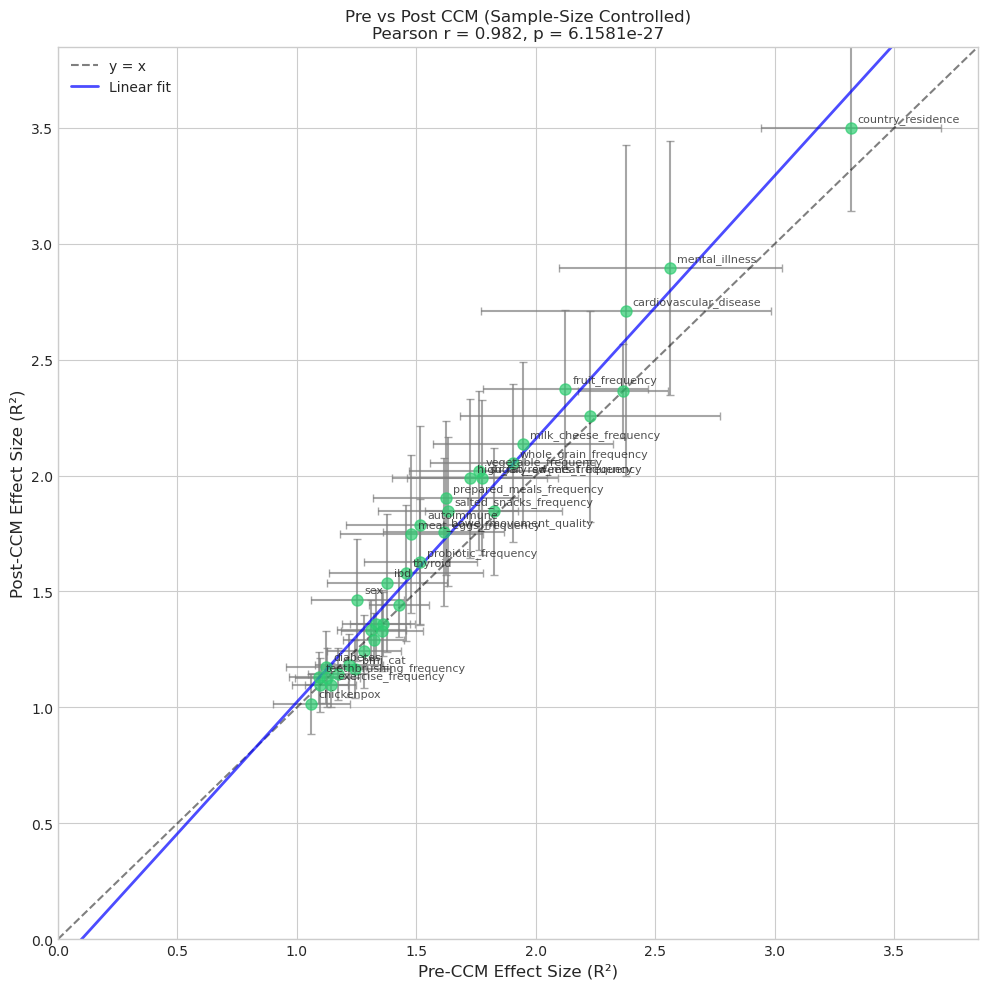

In [22]:
def plot_scatter_with_errorbars(comparison_df, output_path=None):
    """Scatter plot with error bars."""
    fig, ax = plt.subplots(figsize=(10, 10))
    
    ax.errorbar(comparison_df['pre_mean'], comparison_df['post_mean'],
                xerr=comparison_df['pre_std'], yerr=comparison_df['post_std'],
                fmt='o', markersize=8, capsize=3, alpha=0.7,
                color='#2ecc71', ecolor='gray')
    
    max_val = max(comparison_df['pre_mean'].max(), comparison_df['post_mean'].max()) * 1.1
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='y = x')
    
    z = np.polyfit(comparison_df['pre_mean'], comparison_df['post_mean'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(0, max_val, 100)
    ax.plot(x_line, p(x_line), 'b-', alpha=0.7, linewidth=2, label='Linear fit')
    
    for _, row in comparison_df.iterrows():
        if row['significant']:
            ax.annotate(row['category'], 
                       (row['pre_mean'], row['post_mean']),
                       fontsize=8, alpha=0.8,
                       xytext=(5, 5), textcoords='offset points')
    
    corr, p_corr = stats.pearsonr(comparison_df['pre_mean'], comparison_df['post_mean'])
    
    ax.set_xlabel('Pre-CCM Effect Size (R²)', fontsize=12)
    ax.set_ylabel('Post-CCM Effect Size (R²)', fontsize=12)
    ax.set_title(f'Pre vs Post CCM (Sample-Size Controlled)\n'
                 f'Pearson r = {corr:.3f}, p = {p_corr:.4e}', fontsize=12)
    ax.legend(loc='upper left')
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved: {output_path}")
    
    plt.show()
    return fig

fig3 = plot_scatter_with_errorbars(
    comparison_df,
    output_path=os.path.join(OUTPUT_DIR, f'{DATASET_NAME}_scatter_controlled.png')
)

## 14. Summary

In [23]:
print("\n" + "="*70)
print(f"SUMMARY: {DATASET_NAME} Effect Size Analysis (SAMPLE-SIZE CONTROLLED)")
print("="*70)

print(f"\nDataset: {DATASET_NAME}")
print(f"Distance Metric: {DISTANCE_METRIC}")
print(f"Matching Categories: {MATCHING_CATEGORIES}")

print(f"\n--- Original Sample Sizes ---")
print(f"Cases: {len(focus)}, Controls: {len(background)}")
print(f"Imbalance: 1:{len(background)/len(focus):.1f}")

print(f"\n--- Analysis Sample Sizes (Controlled) ---")
print(f"{TARGET_N_CASES} cases + {TARGET_N_CONTROLS} controls = {TARGET_TOTAL} total")
print(f"Bootstrap iterations: {N_BOOTSTRAP}")
print(f"CCM iterations: {N_ITERATIONS}")

print(f"\n--- Case-Control Effect Size ---")
print(f"Pre-CCM:  R² = {cc_pre_all['r_squared'].mean():.4f} ± {cc_pre_all['r_squared'].std():.4f}")
print(f"Post-CCM: R² = {cc_post_all['r_squared'].mean():.4f} ± {cc_post_all['r_squared'].std():.4f}")

delta = cc_post_all['r_squared'].mean() - cc_pre_all['r_squared'].mean()
pct = delta / cc_pre_all['r_squared'].mean() * 100 if cc_pre_all['r_squared'].mean() > 0 else 0
t_stat, p_val = stats.ttest_ind(cc_pre_all['r_squared'].values, cc_post_all['r_squared'].values)

print(f"Change: {delta:+.4f} ({pct:+.1f}%)")
print(f"p-value: {p_val:.4e}")

print(f"\n--- Interpretation ---")
if p_val < 0.05:
    if delta > 0:
        print("✓ Case-control effect INCREASED after CCM")
        print("  → Disease signal is stronger after controlling confounders")
    else:
        print("⚠ Case-control effect DECREASED after CCM")
        print("  → Some original effect was due to confounding")
        print(f"  → Remaining {cc_post_all['r_squared'].mean():.4f} is 'true' signal")
else:
    print("○ No significant difference after CCM")
    print("  → Original effect was robust (not due to confounders)")

print(f"\n--- Confounders with Significant Changes ---")
sig_changes = comparison_df[comparison_df['significant']].sort_values('delta')
for _, row in sig_changes.head(10).iterrows():
    direction = '↓' if row['delta'] < 0 else '↑'
    print(f"  {row['category']}: {row['pre_mean']:.4f} → {row['post_mean']:.4f} ({row['pct_change']:+.1f}%) {direction}")


SUMMARY: AGP Effect Size Analysis (SAMPLE-SIZE CONTROLLED)

Dataset: AGP
Distance Metric: Bray-Curtis
Matching Categories: ['sex', 'age_cat', 'bmi_cat']

--- Original Sample Sizes ---
Cases: 169, Controls: 4672
Imbalance: 1:27.6

--- Analysis Sample Sizes (Controlled) ---
169 cases + 169 controls = 338 total
Bootstrap iterations: 100
CCM iterations: 100

--- Case-Control Effect Size ---
Pre-CCM:  R² = 1.3514 ± 0.2502
Post-CCM: R² = 1.5381 ± 0.2989
Change: +0.1867 (+13.8%)
p-value: 3.2743e-06

--- Interpretation ---
✓ Case-control effect INCREASED after CCM
  → Disease signal is stronger after controlling confounders

--- Confounders with Significant Changes ---
  bmi_cat: 1.2449 → 1.1666 (-6.3%) ↓
  exercise_frequency: 1.1412 → 1.0971 (-3.9%) ↓
  chickenpox: 1.0593 → 1.0155 (-4.1%) ↓
  teethbrushing_frequency: 1.0925 → 1.1295 (+3.4%) ↑
  diabetes: 1.1216 → 1.1727 (+4.6%) ↑
  probiotic_frequency: 1.5169 → 1.6285 (+7.4%) ↑
  thyroid: 1.4559 → 1.5794 (+8.5%) ↑
  bowel_movement_quality: 1

In [24]:
# Export results
comparison_df.to_csv(os.path.join(OUTPUT_DIR, f'{DATASET_NAME}_comparison_controlled.csv'), index=False)
effect_sizes_pre.to_csv(os.path.join(OUTPUT_DIR, f'{DATASET_NAME}_pre_bootstrap.csv'), index=False)
effect_sizes_post.to_csv(os.path.join(OUTPUT_DIR, f'{DATASET_NAME}_post_ccm.csv'), index=False)
cc_pre_all.to_csv(os.path.join(OUTPUT_DIR, f'{DATASET_NAME}_cc_pre_all.csv'), index=False)
cc_post_all.to_csv(os.path.join(OUTPUT_DIR, f'{DATASET_NAME}_cc_post_all.csv'), index=False)

print(f"\nResults exported to {OUTPUT_DIR}/")


Results exported to agp_ccm_analysis_controlled/


## 15. Why This Matters for AGP

### The Extreme Imbalance Problem:
- **169 cases vs 4672 controls** = 1:27.6 ratio
- This is one of the most extreme imbalances possible
- Without correction, pre-CCM effect sizes would be massively inflated

### What Bootstrap Subsampling Does:
1. Randomly samples 169 cases + 169 controls (matching CCM)
2. Repeats 100 times to get a distribution
3. Provides **fair comparison** at same sample size

### Interpretation Guide:
- **If post-CCM ≈ pre-CCM (bootstrap)**: Original effect was real, just sample-size inflated
- **If post-CCM < pre-CCM (bootstrap)**: Some confounding was present
- **If post-CCM > pre-CCM (bootstrap)**: CCM improved signal (rare but possible)